In [25]:
# Import libraries for data handling and numerical operations
import pandas as pd
import numpy as np

# Libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Library for standardizing variables
from sklearn.preprocessing import StandardScaler

# Libraries for hierarchical clustering and dendrograms
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [26]:


# Read the Cereals dataset from the Colab working directory
df = pd.read_csv("/content/Cereals.csv")

# Preview the first few rows to confirm the dataset loaded correctly
df.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100%_Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,25,3,1.0,0.33,68.402973
1,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,25,3,1.0,0.33,59.425505
3,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,25,3,1.0,0.50,93.704912
4,Almond_Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,25,3,1.0,0.75,34.384843


In [27]:
# Check the shape of the dataset (number of rows and columns)
df.shape

(77, 16)

In [28]:
# Display the column names
df.columns

Index(['name', 'mfr', 'type', 'calories', 'protein', 'fat', 'sodium', 'fiber',
       'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups',
       'rating'],
      dtype='object')

In [29]:
# Display basic information about the dataset and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     76 non-null     float64
 9   sugars    76 non-null     float64
 10  potass    75 non-null     float64
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(7), int64(6), object(3)
memory usage: 9.8+ KB


In [30]:
# Display summary statistics for all variables
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,77,77,100%_Bran,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mfr,77,7,K,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,77,2,C,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calories,77.0,NaN,NaN,NaN,106.883117,19.484119,50.0,100.0,110.0,110.0,160.0
protein,77.0,NaN,NaN,NaN,2.545455,1.09479,1.0,2.0,3.0,3.0,6.0
fat,77.0,NaN,NaN,NaN,1.012987,1.006473,0.0,0.0,1.0,2.0,5.0
sodium,77.0,NaN,NaN,NaN,159.675325,83.832295,0.0,130.0,180.0,210.0,320.0
fiber,77.0,NaN,NaN,NaN,2.151948,2.383364,0.0,1.0,2.0,3.0,14.0
carbo,76.0,NaN,NaN,NaN,14.802632,3.907326,5.0,12.0,14.5,17.0,23.0
sugars,76.0,NaN,NaN,NaN,7.026316,4.378656,0.0,3.0,7.0,11.0,15.0


In [31]:
# Check for missing values in each column
df.isna().sum()


,0
name,0
mfr,0
type,0
calories,0
protein,0
fat,0
sodium,0
fiber,0
carbo,1
sugars,1


In [32]:
# Remove rows that contain any missing values
df_clean = df.dropna().copy()

In [33]:
# Check the shape of the dataset after removing missing values
df_clean.shape

(74, 16)

In [34]:
# Drop categorical variables (name, manufacturer, and type)
df_num = df_clean.drop(columns=["name", "mfr", "type"])

In [35]:
# Display information to confirm that only numeric variables remain
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74 entries, 0 to 76
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calories  74 non-null     int64  
 1   protein   74 non-null     int64  
 2   fat       74 non-null     int64  
 3   sodium    74 non-null     int64  
 4   fiber     74 non-null     float64
 5   carbo     74 non-null     float64
 6   sugars    74 non-null     float64
 7   potass    74 non-null     float64
 8   vitamins  74 non-null     int64  
 9   shelf     74 non-null     int64  
 10  weight    74 non-null     float64
 11  cups      74 non-null     float64
 12  rating    74 non-null     float64
dtypes: float64(7), int64(6)
memory usage: 8.1 KB


In [36]:
# Import the StandardScaler for standardizing the variables
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the numeric data and transform it
X_scaled = scaler.fit_transform(df_num)

# Convert the scaled data back into a DataFrame for convenience
X_scaled_df = pd.DataFrame(X_scaled, columns=df_num.columns, index=df_num.index)

# Display the first few rows of the standardized data
X_scaled_df.head()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,-1.878652,1.391180,0.0,-0.393692,3.250706,-2.517206,-0.255940,2.578001,-0.183083,0.948401,-0.202203,-2.099895,1.867565
1,0.658214,0.455295,4.0,-1.792572,-0.072986,-1.741067,0.206001,0.518288,-1.312098,0.948401,-0.202203,0.761919,-0.601791
2,-1.878652,1.391180,0.0,1.187651,2.835245,-1.999780,-0.486911,3.146198,-0.183083,0.948401,-0.202203,-2.099895,1.223491
3,-2.893399,1.391180,-1.0,-0.272050,4.912553,-1.741067,-1.641763,3.288247,-0.183083,0.948401,-0.202203,-1.373763,3.682812
5,0.150841,-0.480589,1.0,0.214517,-0.280717,-1.094285,0.667942,-0.405032,-0.183083,-1.471657,-0.202203,-0.305922,-0.922781


In [37]:
# Import functions for hierarchical clustering and dendrograms
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Perform hierarchical clustering using single linkage and Euclidean distance
Z_single = linkage(X_scaled_df, method="single", metric="euclidean")

# Perform hierarchical clustering using complete linkage and Euclidean distance
Z_complete = linkage(X_scaled_df, method="complete", metric="euclidean")

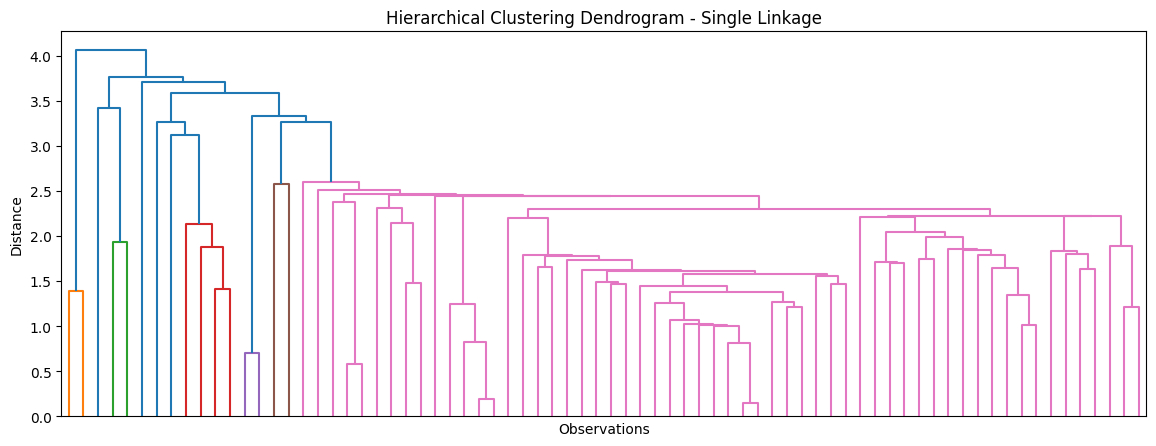

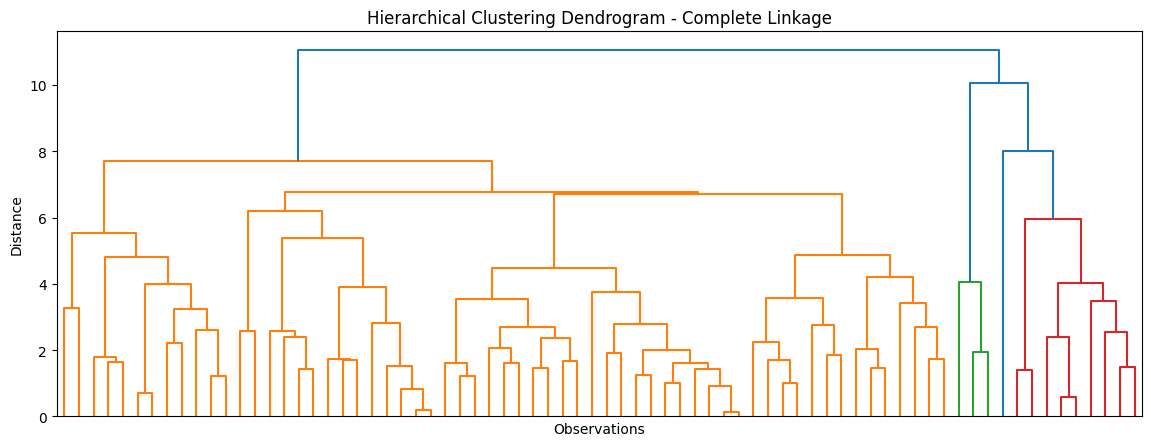

In [38]:
# Plot the dendrogram for single linkage
plt.figure(figsize=(14, 5))
dendrogram(Z_single, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram - Single Linkage")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

# Plot the dendrogram for complete linkage
plt.figure(figsize=(14, 5))
dendrogram(Z_complete, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram - Complete Linkage")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

In the single-linkage dendrogram, the clusters tend to merge gradually, creating a chaining effect. The complete-linkage dendrogram, on the other hand, shows clearer separation between groups and a noticeable jump in merge distance near the top of the tree. For this reason, complete linkage is chosen for the final cluster solution.

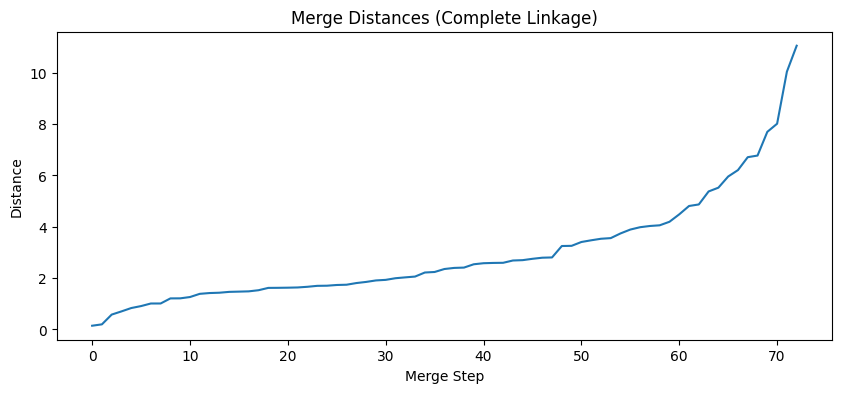

array([ 5.37814493,  5.52539447,  5.96035289,  6.21068808,  6.71417426,
        6.77717359,  7.70184602,  8.01816767, 10.04678881, 11.05886516])

In [39]:
# Examine the merge distances from the complete linkage clustering
merge_distances = Z_complete[:, 2]

# Plot the merge distances to help identify a large jump
plt.figure(figsize=(10, 4))
plt.plot(merge_distances)
plt.title("Merge Distances (Complete Linkage)")
plt.xlabel("Merge Step")
plt.ylabel("Distance")
plt.show()

# Display the largest merge distances
merge_distances[-10:]

The merge distance plot shows a noticeable increase in distance starting around 6. This indicates that beyond this point, relatively dissimilar clusters begin to merge. Therefore, a cutoff distance of about 6 is chosen to form the final clusters.

In [40]:
# Cut the dendrogram at the chosen distance to form clusters
cutoff = 6.0   # Chosen based on the large jump in merge distances
clusters = fcluster(Z_complete, t=cutoff, criterion="distance")

# Display the number of observations in each cluster
pd.Series(clusters).value_counts().sort_index()

,count
1,12
2,2
3,12
4,21
5,14
6,3
7,9
8,1


In [41]:
# Try a slightly higher cutoff to see if clusters merge into more interpretable groups
cutoff = 7.0
clusters_7 = fcluster(Z_complete, t=cutoff, criterion="distance")

pd.Series(clusters_7).value_counts().sort_index()

,count
1,12
2,49
3,3
4,9
5,1


In [42]:
# Try an intermediate cutoff to see if it gives a more balanced solution
cutoff = 6.5
clusters_65 = fcluster(Z_complete, t=cutoff, criterion="distance")

# Display the number of observations in each cluster
pd.Series(clusters_65).value_counts().sort_index()

,count
1,12
2,14
3,21
4,14
5,3
6,9
7,1


Looking at the complete-linkage dendrogram and the merge distance plot, the biggest jump in distance appears between about 6 and 7. I tried a few cutoff values in this range. A cutoff of 7.0 produced one very large cluster, while 6.0 created several small clusters. The cutoff of 6.5 gave a better balance between the number of clusters and their sizes, resulting in 7 clusters that are easier to interpret. Therefore, 6.5 was chosen as the final cutoff distance.

In [43]:
# Add the final cluster labels to the numeric dataset
clustered = df_num.copy()
clustered["cluster"] = clusters

# Compute the mean of each variable within each cluster (cluster profiles)
centroids = clustered.groupby("cluster").mean().round(2)

# Display the cluster centroids
centroids

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
cluster,,,,,,,,,,,,,
1,135.00,3.17,1.67,180.42,3.54,15.62,10.92,172.08,37.50,2.92,1.29,0.76,36.16
2,110.00,6.00,1.00,260.00,1.50,16.50,2.00,80.00,25.00,1.00,1.00,1.12,51.95
3,106.67,2.08,0.42,242.50,0.67,20.25,3.25,48.75,50.00,2.25,1.00,1.01,41.91
4,110.95,1.52,1.00,172.38,0.57,12.62,11.29,45.95,25.00,1.67,1.00,0.89,28.85
5,101.43,3.00,1.29,160.00,2.96,13.96,5.36,116.79,25.00,2.50,1.00,0.64,47.59
6,63.33,4.00,0.67,176.67,11.00,6.67,3.67,310.00,25.00,3.00,1.00,0.39,73.84
7,82.22,2.44,0.11,1.67,2.11,15.33,2.33,90.56,11.11,2.00,0.87,0.85,63.02
8,120.00,3.00,5.00,15.00,2.00,8.00,8.00,135.00,0.00,3.00,1.00,1.00,33.98


In [44]:
# Count how many cereals are in each cluster
cluster_sizes = clustered["cluster"].value_counts().sort_index()
cluster_sizes

,count
cluster,
1,12
2,2
3,12
4,21
5,14
6,3
7,9
8,1


The table above shows how many cereals fall into each cluster. The clusters are not evenly sized, with some clusters much larger than others. This indicates that the clustering solution produces groups of very different sizes, which is important to consider when evaluating how practical each cluster is for real-world use.

To determine the healthiest cluster, I compared the clusters using key variables such as calories, sugar, fat, sodium, fiber, protein, and rating. A healthy cereal should be relatively low in sugar, fat, and calories, and higher in fiber and protein. Based on the cluster centroids, Cluster 6 stands out as the healthiest option. It has very low calories, low sugar and fat, the highest fiber content, and the highest average rating. Although its sodium level is not the lowest among all clusters, the overall nutritional profile is still the most balanced and health-focused compared to the others. For this reason, Cluster 6 is identified as the best choice for school children.                                                                       However, Cluster 6 contains only three cereals, which means it cannot cover all five school days without repetition. In practice, these cereals can serve as the core healthy options, with one or two similar cereals from the next healthiest cluster added to complete the five-day menu while maintaining nutritional standards.

To better understand what cereals belong to the healthiest cluster, I listed the cereals in Cluster 6 and examined their nutritional values.

In [45]:
# Attach cluster labels back to the cleaned dataset (including names)
df_with_clusters = df_clean.copy()
df_with_clusters["cluster"] = clusters

# Display cereals in the healthiest cluster (Cluster 6)
healthy_cluster = 6
df_with_clusters.loc[df_with_clusters["cluster"] == healthy_cluster,
                     ["name", "calories", "protein", "fat", "sodium", "fiber", "sugars", "rating"]]

,name,calories,protein,fat,sodium,fiber,sugars,rating
0,100%_Bran,70,4,1,130,10.0,6.0,68.402973
2,All-Bran,70,4,1,260,9.0,5.0,59.425505
3,All-Bran_with_Extra_Fiber,50,4,0,140,14.0,0.0,93.704912


The cereals in Cluster 6 include products such as 100% Bran, All-Bran, and All-Bran with Extra Fiber. These cereals are generally low in calories, high in fiber, and low in sugar, which is consistent with the characteristics seen in the cluster centroid. This provides concrete examples that support the conclusion that Cluster 6 represents the healthiest group of cereals.